# ARIMA, ETS <a class="tocSkip">

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from scipy import stats
from statsmodels.graphics import tsaplots
from sktime.utils.plotting import plot_correlations
from itertools import product

In [ ]:
import warnings
warnings.simplefilter("ignore")

In [ ]:
params = {'lines.linewidth': 4,
          'lines.solid_capstyle': 'butt',
          'axes.labelsize': 'large',
          'axes.axisbelow': True,
          'axes.grid': True,
          'axes.linewidth': 3.0,
          'axes.titlesize': 'x-large',
          'grid.linestyle': '-',
          'grid.linewidth': 1.0,
          'xtick.major.size': 0,
          'xtick.minor.size': 0,
          'ytick.major.size': 0,
          'ytick.minor.size': 0,
          'figure.subplot.left': 0.08,
          'figure.subplot.right': 0.95,
          'figure.subplot.bottom': 0.07,
          'figure.figsize': (10.8, 7.8),
          'figure.autolayout': True,
          'figure.dpi': 300,
          'font.size': 24.0 }
plt.rcParams.update(params)

In [ ]:
pd.options.display.max_rows = 999
%cd ..
%cd ..
%env PYTHONPATH=.

In [ ]:
np.random.seed(555)

In [ ]:
from sktime.forecasting.arima import ARIMA
from sktime.forecasting.model_selection import ExpandingWindowSplitter
from sktime.forecasting.model_evaluation import evaluate
from sktime.forecasting.arima import AutoARIMA
from scipy.stats import ttest_1samp, shapiro
from statsmodels. tsa.stattools import adfuller, kpss
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from sktime.transformations.series.boxcox import BoxCoxTransformer

In [ ]:
from sktime.performance_metrics.forecasting import MeanAbsoluteError,MeanAbsolutePercentageError
from sklearn.metrics import r2_score

def metrics_report(y_true,
                   y_pred
                  ):
    
    """
    Функция оценки качества прогноза. Оценивает персентили распределения ошибки 
    (медиану, среднее, 3й квартиль и 95-персентиль) 
    по абсолютной и относительной процентной ошибки для прогноза с помощью модели (y_pred) и
    для базового прогноза, равному среднему значению вр.
    
    """
    
    mape_func = MeanAbsolutePercentageError()
    mae_func = MeanAbsoluteError()
    
    y_true_mean = y_true.mean()*np.ones(shape=(len(y_true),))
    
    
    mapes = mape_func.evaluate_by_index(y_true,y_pred)*100
    maes = mae_func.evaluate_by_index(y_true,y_pred)
    
    
    mapes_zero = mape_func.evaluate_by_index(y_true,y_true_mean)*100
    maes_zero = mae_func.evaluate_by_index(y_true,y_true_mean)
    
    def quan_75(y,quan=0.75):
        return y.quantile(quan)

    def quan_95(y,quan=0.95):
        return y.quantile(quan)
    
    stats_list = ['mean','median',quan_75,quan_95,'std']
    
    res = pd.DataFrame([maes.agg(stats_list),
                        maes_zero.agg(stats_list),
                        mapes.agg(stats_list),
                        mapes_zero.agg(stats_list)],
                       index=['maes','maes_zero','mapes','mapes_zero'])
    
    res.loc["r2",:] = r2_score(y_true, y_pred)
    
    return res

# Ряды Фурье

В этом разделе мы разберемся, как моделировать вр с помощью рядов Фурье, как строить периодограммы для различных временных рядов и как моделировать длинную сезонность с помощью рядов Фурье.

## Построение периодограмм

Для начала посмотрим, как выглядят периодограммы известных вр. Пусть у нас будут подневные данные за 10 лет.

In [ ]:
t_max = 10 # 10 лет
T = 365 # период колебаний - дней в году
N = t_max*T # всего наблюдений в генерируемом ВР
bandwidth = 1/N
t = np.linspace(0, t_max, N) 
freq_ny = 1/2 #Nyquist freq
tot_freq_cnt = N/2

белый шум

In [ ]:
total = np.zeros(N)
total += np.random.normal(size=N) 

In [ ]:
plt.plot(t, total, label='total')
plt.xlabel('Year')
plt.ylabel('Amplitude')
plt.legend()

Преобразование Фурье хорошо реализовано в библиотеке scipy

In [ ]:
from scipy import fft

In [ ]:
# прямое преобразование Фурье
fft_values = fft.fft(total)

In [ ]:
print(fft_values.dtype,fft_values.shape)

In [ ]:
fft_values

изобразим периодограмму без сглаживания

In [ ]:
fft_real = np.abs(fft_values) #амплитуда гармоники 

In [ ]:
# и соответствующие частоты
freq_values = fft.fftfreq(N, 1/365)

In [ ]:
len(freq_values)

In [ ]:
# согласно документации, частоты хранятся в таком порядке:
# сначало нулевая, затем c шагом 1/N от 1/N до T/2 и потом в обратном порядке со знаком минус
print(freq_values[:3],freq_values[N//2-2:N//2+2],freq_values[-3:])

In [ ]:
# график периодограммы - для белого шума выглядит также, как и исходный ряд
# Другими словами, такой вр содержит в одинаковом количестве все частоты, подобно тому, 
#как белый цвет содержит в себе все остальные цвета - откуда и название ряда - белый шум
plt.plot(freq_values, fft_real, label='calculated')
plt.xlabel('Freq (Hz)')
plt.ylabel('Amplitude')
plt.legend()

случайное блуждание

In [ ]:
total = np.zeros(N)
total += np.cumsum(np.random.normal(size=N))

In [ ]:
plt.plot(t, total, label='total')
plt.xlabel('Year')
plt.ylabel('Amplitude')
plt.legend()

In [ ]:
fft_values = fft.fft(total)
fft_real = np.abs(fft_values) #амплитуда гармоники 

In [ ]:
# периодограмма случайного блуждания - пик в 0, и потом быстрое убывание амплитуды с ростом частоты
plt.plot(freq_values, fft_real, label='calculated')
plt.xlabel('Freq (Hz)')
plt.ylabel('Amplitude')
plt.legend()

In [ ]:
# амплитуды симметричных частот одинаковы
pd.DataFrame(zip(freq_values, fft_real))

теперь попробуем смоделировать вр с несколькими детерминированными частотами и шумом

In [ ]:
amp = np.array([2, .7, .1, 0.5]) # амплитуды частот
freq = np.array([1, 2, 10, 15]) # частоты - всего 4 частоты

In [ ]:
total = np.zeros(N)
components = []

n_freq = len(freq)

# добавляем детерминированные частоты
for i in range(n_freq):
    current = amp[i]*np.cos(2*np.pi*freq[i]*t)
    total += current
    
    components.append(current)
    plt.plot(t, current, label='f='+str(freq[i]), lw=1)

total += np.random.normal(size=N,scale=3) # добавляем шум

In [ ]:
plt.plot(t, total, label='total')
plt.xlabel('Year')
plt.ylabel('Amplitude')
plt.legend()

In [ ]:
# визуально видно только самую медленную частоту
plt.plot(t, total, label='total')
plt.xlabel('Year')
plt.ylabel('Amplitude')
plt.legend()
plt.xlim(0,2)

In [ ]:
fft_values = fft.fft(total)

In [ ]:
# нормировка амплитуд для обратного преобразования фурье
fft_real = 2.0/N * np.abs(fft_values)

In [ ]:
# большую амплитуду имеет только 6 наблюдений
np.where(fft_real>0.3)

In [ ]:
plt.plot(freq_values[0:N//2], fft_real[0:N//2], label='calculated')
plt.scatter(freq, amp, s=100, zorder=3, label='original')
plt.vlines(x=freq_ny,ymin=0,ymax=2)
plt.xlabel('Freq (Hz)')
plt.ylabel('Amplitude')
plt.legend()
#plt.xlim(0,20)

Видим, что несмотря на шум, ряд фурье успешно детектировал 3 из 4 частот в исходном вр. Одну не получилось - амплитуда была слишком маленькой, и она утонула в белом шуме.

In [ ]:
Sun = pd.read_csv('data/sun.csv')
Sun['YEAR'] = pd.to_datetime(Sun['YEAR'].astype(int).astype(str) + '-01-01')
Sun.set_index("YEAR",inplace=True)

In [ ]:
Sun.plot()

In [ ]:
N = len(Sun)
fft_values = fft.fft(Sun.values,axis=0)

In [ ]:
freq_values = fft.fftfreq(N,)

In [ ]:
# периодограмма ряда солнечной активности
# основной вклад вност частоты около 0.1
fig, ax = plt.subplots(1)
ax.plot(freq_values[:N//2], np.abs(fft_values[:N//2]));

In [ ]:
airline = pd.read_csv('data/international-airline-passengers.csv', sep=';')
airline['Month'] = pd.to_datetime(airline['Month']+'-01')
airline.set_index('Month', inplace=True)

In [ ]:
airline.plot()

In [ ]:
# прямое преобразование фурье
fft_values = fft.fft(airline,axis=0)
N = len(airline)
freq_values = fft.fftfreq(N, 1/12) # все частоты по оси х отображаются относительно частоты "1 раз за год"

In [ ]:
# периодограмма ряда авиаперевозок - видим пик около 0 и в частотах, кратных частоте "1 раз за год"
fig, ax = plt.subplots(1)
ax.plot(freq_values[:N//2], np.abs(fft_values[:N//2]));

## Аппроксимация вр

In [ ]:
Sun.plot()

In [ ]:
# преобразование фурье, частота, амплитуда и фаза комплексных чисел
x_freqdom = fft.fft(Sun.values,axis=0)
N=len(Sun.values)
fourier = pd.DataFrame(x_freqdom)
fourier['freq'] = fft.fftfreq(N,1) 
fourier['amp'] = np.absolute(x_freqdom) / N
fourier['phase'] = np.angle(x_freqdom)

In [ ]:
fourier.sort_values(by='amp',ascending=False)

In [ ]:
# график первых компонент Фурье
t = np.arange(0, len(Sun))
for i in range(4):
    plt.plot(t, fourier.iloc[i,2] * np.cos(2 * np.pi * fourier.iloc[i,1] * t  + fourier.iloc[i,3]))

In [ ]:
N = len(Sun)
fft_values = fft.fft(Sun.values,axis=0)

In [ ]:
freq_values = fft.fftfreq(N,)

In [ ]:
# периодограмма ряда солнечной активности
# основной вклад вност частоты около 0.1
fig, ax = plt.subplots(1)
ax.plot(freq_values[:N//2], np.abs(fft_values[:N//2]));

In [ ]:
fourier.sort_values(by='amp',ascending=False,inplace=True)

In [ ]:
fourier

In [ ]:
# график первых компонент Фурье по амплитуде
t = np.arange(0, len(Sun))
for i in range(4):
    plt.plot(t, fourier.iloc[i,2] * np.cos(2 * np.pi * fourier.iloc[i,1] * t  + fourier.iloc[i,3]))

In [ ]:
# фильтр низких частот
filtered = fft_values.copy()
filtered[(np.abs(freq_values) > 0.15)] = 0

In [ ]:
# обратное преобразование Фурье
signal_filtered = np.real(fft.ifft(filtered, axis=0))

In [ ]:
# мы очистили 70% всех частот, при этом вр практически не изменился
plt.plot(signal_filtered,c='red')
plt.plot(Sun.values)

In [ ]:
# полосовой фильтр
filtered = fft_values.copy()
filtered[~((np.abs(freq_values) < 0.12) & (np.abs(freq_values) > 0.09))] = 0

In [ ]:
# обратное преобразование Фурье
signal_filtered = np.real(fft.ifft(filtered, axis=0))

In [ ]:
plt.plot(signal_filtered,c='red')
plt.plot(Sun.values)

посмотрим, как работает экстраполяция с помощью рядов Фурье в сравнении с моделью ARIMA. Посмотрим на короткий и длительный промежутки времени

In [ ]:
from sktime.forecasting.arima import ARIMA

In [ ]:
forecaster_short = ARIMA((3,0,3))
forecaster_long = ARIMA((3,0,3))

In [ ]:
forecaster_long.fit(Sun.values[:-100])
forecaster_short.fit(Sun.values[:-10])

In [ ]:
def fourierExtrapolation(x, n_predict, n_harm = 20, inner_freq = 1.0):
    """
    Функция для экстраполяции рядов Фурье. По вр х делает предикт на n_predict шагов
    с помощью топ n_harm гармоник по амплитуде.
    Возвращает исходный ряд + экстраполяцию на n_predict шагов
    
    https://gist.github.com/tartakynov/83f3cd8f44208a1856ce
    """
    n = x.size
    t = np.arange(0, n)

    x_freqdom = fft.fft(x,axis=0)  # x in frequency domain
    f = fft.fftfreq(n,inner_freq)              # frequencies
    indexes = list(range(n))
    # sort indexes by frequency, lower -> higher
    indexes.sort(key=lambda i: np.absolute(f[i]))

    t = np.arange(0, n + n_predict)
    restored_sig = np.zeros(t.size)
    for i in indexes[:1 + n_harm * 2]:
        ampli = np.absolute(x_freqdom[i]) / n   # amplitude
        phase = np.angle(x_freqdom[i])          # phase
        restored_sig += ampli * np.cos(2 * np.pi * f[i] * t * inner_freq  + phase)
    return restored_sig

In [ ]:
# графическое сравнение прогнозов на длинном промежутке
plt.plot(fourierExtrapolation(Sun.values[:-100,:],100,25,1),c='red')
plt.plot(Sun.values,c='green')
plt.plot(np.r_[Sun.values[:-100,:],forecaster_long.predict(fh=list(range(1,101)))])

In [ ]:
# графическое сравнение прогнозов на коротком промежутке
plt.plot(fourierExtrapolation(Sun.values[:-10,:],10,100,1)[-10:],c='red')
plt.plot(Sun.iloc[-10:].values,c='green')
plt.plot(forecaster_short.predict(fh=list(range(1,11))))

сравнение метрик на длинном промежутке - ряды фурье чуть более адекватно описывают вр, хотя далеко от идеального, т.к. у исходного вр непостоянный период колебаний

In [ ]:
metrics_report(Sun.values[-100:], 
               fourierExtrapolation(Sun.values[:-100,:],100,25,1)[-100:])

In [ ]:
metrics_report(Sun.values[-100:], 
               forecaster_long.predict(fh=list(range(1,101))))

In [ ]:
# при увеличении кол-ва гармоник качество прогноза не улучшается 
# кол-во гармоник - гиперпараметр, который нужно подбирать
metrics_report(Sun.values[-100:], 
               fourierExtrapolation(Sun.values[:-100,:],100,50,1)[-100:])

сравнение метрик на коротком промежутке - здесь модель arma прогнозирует очень хорошо в отличии от рядов Фурье

In [ ]:
metrics_report(Sun.values[-10:], 
               fourierExtrapolation(Sun.values[:-10,:],10,25,1)[-10:])

In [ ]:
metrics_report(Sun.values[-10:], 
               forecaster_short.predict(fh=list(range(1,11))))

In [ ]:
airline = pd.read_csv('data/international-airline-passengers.csv', sep=';')
airline['Month'] = pd.to_datetime(airline['Month']+'-01')
airline.set_index('Month', inplace=True)

In [ ]:
airline.plot()

In [ ]:
# прямое преобразование фурье
fft_values = fft.fft(airline,axis=0)
N = len(airline)
freq_values = fft.fftfreq(N, 1/12) # все частоты по оси х отображаются относительно частоты "1 раз за год"

In [ ]:
# периодограмма ряда авиаперевозок - видим пик около 0 и в частотах, кратных частоте "1 раз за год"
fig, ax = plt.subplots(1)
ax.plot(freq_values[:N//2], np.abs(fft_values[:N//2]));

In [ ]:
# фильтр высоких частот + преобразование Фурье
filtered = fft_values.copy()
filtered[(np.abs(freq_values) > 3.3)] = 0
signal_filtered = np.real(fft.ifft(filtered, axis=0))

In [ ]:
#у восстановленного ряда наблюдаются сильные отклонения на краях отрезка (0,T)
plt.plot(airline.values)
plt.plot(signal_filtered,c='red')

In [ ]:
#потому что ряды фурье не умеют описывать трендовую компоненту
plt.plot(airline.values)
plt.plot(fourierExtrapolation(airline.values,0,1,1),c='red')
plt.plot(fourierExtrapolation(airline.values,0,4,1),c='black')

Для преобразования вр в частотный спектр обязательно в первую очередь нужно провести операцию детрендирования!

Давайте это сделаем

In [ ]:
from sktime.transformations.series.boxcox import BoxCoxTransformer
def BC_inverse(y, lam, sig):
    """Back transform Box-Cox with Bias correction.
    See https://robjhyndman.com/hyndsight/backtransforming
    """
    if lam == 0:
        return np.exp(y) * (1 + 0.5 * sig**2)
    else:
        res = np.power(lam*y + 1., 1/lam)
        res *= (1 + 0.5 * sig**2 * (1 - lam) / (lam*y + 1.)**2)
        return res

In [ ]:
from sktime.transformations.series.detrend import Detrender
from sktime.forecasting.trend import PolynomialTrendForecaster

In [ ]:
# также помимо операции детрендирования обеспечим одинаковую амплитуду для сезонных колебаний
transformer = BoxCoxTransformer(method = "guerrero",sp=12)
airline_box = transformer.fit_transform(airline)

In [ ]:
# выделяем из ряда полиномный тренд
airline_detrend = Detrender(PolynomialTrendForecaster(degree=2)).fit_transform(airline_box)

In [ ]:
airline_detrend.plot()

In [ ]:
# прямое преобразование фурье
fft_values = fft.fft(airline_detrend,axis=0)
N = len(airline)
freq_values = fft.fftfreq(N, 1/12)

In [ ]:
# теперь основные пики на периодограмме связаны с сезонностью
fig, ax = plt.subplots(1)
ax.plot(freq_values[:N//2], np.abs(fft_values[:N//2]));

In [ ]:
# фильтр высоких частот + преобразование Фурье
filtered = fft_values.copy()
filtered[np.abs(freq_values) > 4.5] = 0
signal_filtered = np.real(fft.ifft(filtered,axis=0))

In [ ]:
# достаточно точно восстановили исходный ряд
plt.plot(airline_detrend.values)
plt.plot(signal_filtered)

## Моделирование сезонной компоненты

Теперь попробуем с помощью рядов Фурье смоделировать сезонную компоненту

In [ ]:
# Выделим в test последние 40 наблюдений
test_idx = 40

In [ ]:
# попробуем тем же методом посчитать сезонность
ses_extra = fourierExtrapolation(airline_detrend.iloc[:-test_idx],test_idx,25)

In [ ]:
# на графике с фактической и прогнозной сезонностью видим, что предсказанная сезонность начинает
# смещаться относительно фактической
plt.plot(ses_extra,c='red')
plt.plot(airline_detrend.values)

Этот эффект называется "растекание частоты" (frequency leakage). Его причина - длина ряда не кратна частоте сезонной компоненты

In [ ]:
# последнее наблюдение заканчивается на 8 месяце, а не на 12
airline_detrend.iloc[:-test_idx].tail()

In [ ]:
# оценим самый значимые по амплитуде частоты
x_freqdom = fft.fft(airline_detrend.iloc[:-test_idx],axis=0)
n = len(airline_detrend.iloc[:-test_idx])
fourier = pd.DataFrame(x_freqdom)
fourier['freq'] = fft.fftfreq(n,1/12) 
fourier['amp'] = np.absolute(x_freqdom) / n
fourier['phase'] = np.angle(x_freqdom)

In [ ]:
# видно, что эти частоты близки к значениям, кратным 1/12, но не равны ей
fourier.sort_values(by='amp',ascending=False)

давайте попробуем оценить сезонность с целым периодом

In [ ]:
# Выделим в test последние 36 наблюдений
test_idx_full = 36

In [ ]:
# обучающая выборка заканчивается в декабре
airline_detrend.iloc[:-test_idx_full].tail()

In [ ]:
# оценим самый значимые по амплитуде частоты
x_freqdom = fft.fft(airline_detrend.iloc[:-test_idx_full],axis=0)
n = len(airline_detrend.iloc[:-test_idx_full])
fourier = pd.DataFrame(x_freqdom)
fourier['freq'] = fft.fftfreq(n,1/12) 
fourier['amp'] = np.absolute(x_freqdom) / n
fourier['phase'] = np.angle(x_freqdom)

In [ ]:
# здесь частоты кратны 1/12
fourier.sort_values(by='amp',ascending=False)

In [ ]:
# на графике с фактической и прогнозной сезонностью видим, что смещение между линиями пропало
plt.plot(fourierExtrapolation(airline_detrend.iloc[:-test_idx_full],40,25),c='red')
plt.plot(airline_detrend.values)

Ряды Фурье применяется для прогнозирования рядом с длинными сезонностями, например, для моделирования годовой сезонности в подневных данных, чтобы не вводить 365 бинарных переменных. Для более коротких сезонностей можно использовать бинарные переменные. При моделировании сезонности с помощью рядов Фурье стоит всегда помнить про необходимость детрендировать ряд, а также про эффект "растекания частоты".

# Проверка остатков

Остатки — разность между фактом и прогнозом:
    
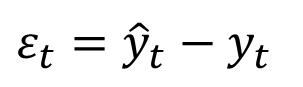

Желательные свойства остатков:
1. Несмещённость — равенство среднего значения нулю
2. Стационарность — отсутствие зависимости от времени
3. Неавтокоррелированность — отсутствие неучтённой зависимости от предыдущих наблюдений
4. «Нормальность» - имеют нормальное распределение
5. Гомоскедастичность — однородность дисперсии


Если остатки модели нормальны и гомоскедастичны, предсказательные интервалы определяются теоретически. Например, для прогноза на следующую точку предсказательный интервал — $\hat{y}_{t+1}\pm1.96\sigma^2$

Если нормальность или гомоскедастичность не выполняется, предсказательные интервалы можно оценить с помощью симуляции. 

Для каждого свойства мы будем проверять соответствующие гипотезы. Давайте вспомним примерный алгоритм проверки гипотез:

1. У нас имеется выборка $Y_t = (y_1,y_2,...,y_t)$,  которая имеет неизвестное распределение $y_t \sim P$
2. Мы делаем предположение об этом распределении (нулевая гипотеза) $H_0: P \in \omega$ и формируем альтернативную гипотезу $H_0: P \notin \omega$
3. Далее мы собираем статистику $T(y_t)$, которая имеет известное распределение $T(y_t) \sim F(Y_t)$ при справедливости нулевой гипотезы, а если справедлива альтернатива, то распределение статистики — какое-то другое $T(y_t) \sim F'(Y_t)$.
4. Подсчитываем значение статистики для нашей выборки: $T(y_t) = t$
5. Подсчитываем достигаемый уровень значимости $p(y_t)$ - вероятность при $H_0$ получить $T(y_t) = t$ или более экстремальное значение статистики $p(y_t) = P(T \ge t| H_0)$
6.Гипотеза отвергается при $p(y_t) \le \alpha$, где $\alpha$ - уровень значимости

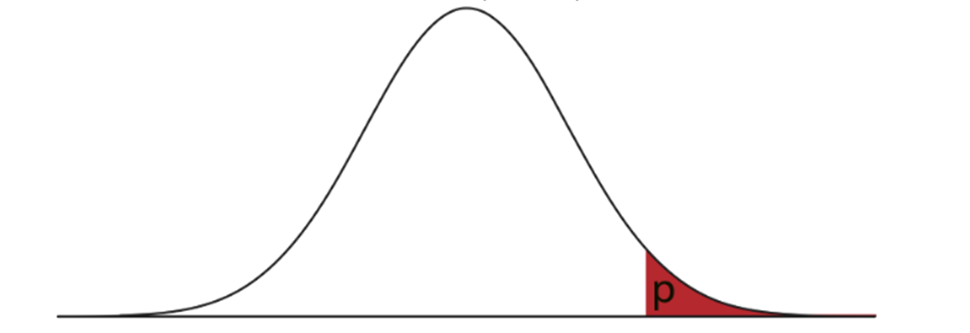

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
arma22_model = sm.tsa.ArmaProcess(ar=[1,0.5,0.55],ma=[1, -0.4, 0.3],nobs=1000)
arma22_ts = pd.Series(arma22_model.generate_sample(burnin=10000))
model_aic = ARIMA(arma22_ts,order=(2,0,3)).fit()

In [ ]:
model_aic.plot_diagnostics(figsize=(25,20));

## Проверка на несмещенность

### Если остатки распределены "около"-нормально

В этом случае используется Т-тест Стьюдента. Он проверяет нулевую гипотезу о равенстве среднего значения $\overline{e_{t}}$ выборки $e_{t} = (e_1,..e_t)$ определенному значению

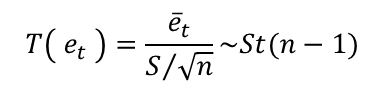

где $S$ - выборочное стандартное отклонение.

In [ ]:
from scipy.stats import ttest_1samp

In [ ]:
model_aic.resid.mean()

In [ ]:
ttest_1samp(model_aic.resid,0)

In [ ]:
ttest_1samp(model_aic.resid,0.5)

### Если остатки распределены совсем "ненормально"

Если центральная предельная теорема не всегда применима: иногда распределения бывают слишком скошенные, иногда выборка недостаточно большая, чтобы распределение ее выборочного среднего можно было считать нормальным, рекомендуется применять критерий Уилкоксона, если распределение симметрично относительно медианы, в противном случае - критерий Знаков

Критерий Уилкоксона

Критерий Уилкоксона проверяет нулевую гипотезу о равенстве медианы $ med(e_{t}) = m_0$ выборки $e_{t} = (e_1,..e_t)$ определенному значению 
Исходный ВР упорядочивают по возврастанию и проверяют следующую статистику о рангах

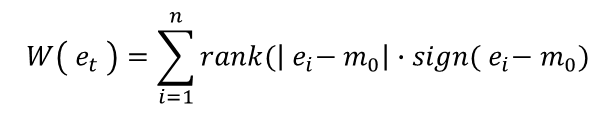

При справедливости нулевой гипотезы каждый из рангов в выборке мог с одинаковой вероятностью реализоваться с любым знаком $(sign(e_i − m_0))$: и с «+», и с «−». Таким образом, получается 2n вариантов
распределения знаков по рангам. Перебирая все эти варианты, для каждого из них можно вычислить значение статистики. При $n>20$ имеют нормальную аппроксимацию

In [ ]:
from scipy.stats import wilcoxon

In [ ]:
wilcoxon(model_aic.resid)

In [ ]:
wilcoxon(model_aic.resid-0.5)

Критерии знаков

Проверяет проверяет нулевую гипотезу о равенстве медианы $ med(e_{t}) = m_0$ выборки $e_{t} = (e_1,..e_t)$ определенному значению. Обладают невысокой мощностью, но они крайне универсальны и практически ничего не требуют от данных, поэтому они очень полезны на практике. Собирает статиститику $T(e_t) = \sum^{n}_{i = 1}[e_i>m_0]$, которая при справедливости нулевой гипотезы имеет биномиальное распределение

In [ ]:
from statsmodels.stats.descriptivestats import sign_test

In [ ]:
sign_test(model_aic.resid)

In [ ]:
sign_test(model_aic.resid,0.5)

## Критерии проверки на стационарность временного ряда

Критерии проверки на стационарность также называются критериями проверки на единичный корень, т.к.

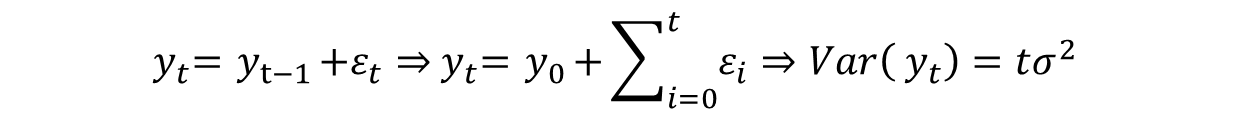

### Критерий Дики-Фуллера

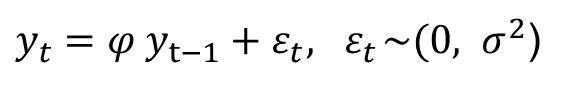

Нулевая гипотеза $H_0: \phi=1$ - ряд нестационарен против альтернативы $H_0: \phi<1$ . Статистика $T(y_t) = \frac{\hat{\phi}-\phi}{s_{\hat{\phi}}}$ имеет табличное распределение.

Почти всегда на практике применяется Расширенный тест Дики — Фуллера (Augmented DF) – в регрессии используется не один лаг авторегрессии, а несколько

In [ ]:
from statsmodels. tsa.stattools import adfuller

In [ ]:
adfuller(model_aic.resid)

### Критерий КПСС

Критерий КПСС проверяет гипотезу о стационарности временного ряда вокруг детерминированного тренда:

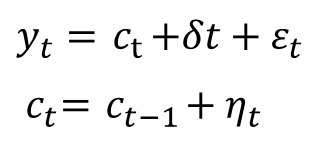

Рассматривается нулевая гипотеза, что ряд стационарен $H_0: \sigma_{\eta_t} = 0$ против альтернативы, что ряд нестационарен $\sigma_{\eta_t} \ne 0$. Статистика критерия

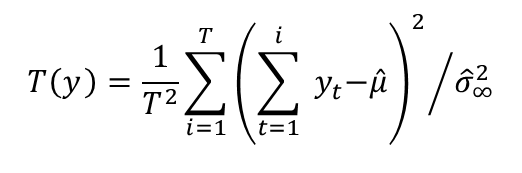

имеет специальное табличное распределение, а $\sigma_{\infty} = 0$ - Стандартная ошибка в форме Ньюи-Веста

In [ ]:
from statsmodels. tsa.stattools import kpss

In [ ]:
kpss(model_aic.resid)

При одновременном применении критериев KPSS и ADF могут получиться следующие результаты:

    Вариант 1: Оба теста говорят, что ряд нестационарный – значит, ряд действительно нестационарный

    Вариант 2: Оба теста говорят, что ряд стационарный – ряд стационарный

    Вариант 3: KPSS говорит, что ряд стационарный, а ADF говорит, что ряд нестационарный – значит, у вр существует детерминированный тренд, который необходимо убрать, чтобы получить стационарный вр

    Вариант 4: KPSS говорит, что ряд нестационарный, а ADF - что ряд стационарный – значит, у вр существует стохастический тренд, который необходимо убрать, чтобы получить стационарный вр



## Проверка на нормальность

### Q-Q график

In [ ]:
x0 = np.random.normal(size = 10000)

In [ ]:
from statsmodels.graphics.gofplots import qqplot

In [ ]:
qqplot(x0,line='45');

In [ ]:
x1 = np.random.normal(scale=0.2,size = 10000)

In [ ]:
sns.histplot(x0,bins=20,alpha=0.3)
sns.histplot(x1,bins=20,alpha=0.3)

In [ ]:
qqplot(x1,line='45',scale=1);

In [ ]:
qqplot(x1,line='s',scale=1);

In [ ]:
qqplot(model_aic.resid,line='s');

### Критерий Шапиро-Уилка

Критерий Шапиро-Уилка используется для проверки гипотезы $H_0$: «случайная величина X распределена нормально» и является одним наиболее эффективных критериев проверки нормальности.  Критерий Шапиро-Уилка основан на оптимальной линейной несмещённой оценке дисперсии к её обычной оценке методом максимального правдоподобия. Статистика критерия имеет вид:

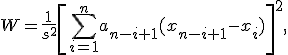

где $s$ - средневыборочное отклонение, $a_{n-i+1}$ - специальные табличные коэффициенты.

In [ ]:
from scipy.stats import shapiro

In [ ]:
shapiro(model_aic.resid)

In [ ]:
model_aic.resid.plot()

In [ ]:
shapiro(x1)

## Дополнительные критерии проверки остатков

###  Проверка на неавтокоррелированность (Q-критерий Льюнга-Бокса)

Критерий Льюнга-Бокса проверяет остатки на отсутствие автокореляций (формализует графическую проверку королеллограммы). Нулевая гипотеза $H_0 = r_1 = r_2 = ... = r_p = 0$ против альтернативы $H_1$ - $H_0$ неверна. Статистика критерия - 

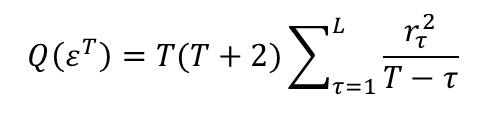

имеет распределение $\chi^2_{L-K}$, где 𝐾 — число настраиваемых параметров модели ряда, 𝐿 – число лагов для проверки. Разработан специально для проверки остатков модели

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [ ]:
acorr_ljungbox(model_aic.resid,model_df=0,lags=10)

### Проверка на гомоскедастичность (критерий Бройша-Пагана) 

Критерий проверяет остатки модели на гомоскедастичность (отсутствие зависимости от х), строя линейную модель на квадрат остатков. Нулевая гипотеза -  $\sigma_1=\sigma_2=...=\sigma_p = const$, против альтернативы, что $H_0$ неверна. Статистика критерия - $T(e_t) = nR^2$ имеет распределение $\chi^2$, где $R^2$, - коэффициент детерминации при регрессии квадратов остатков $e_t$ исходной модели  на время. 

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

In [ ]:
het_breuschpagan(model_aic.resid.values,
                 sm.add_constant(np.array(list(range(len(model_aic.resid.dropna()))))))

In [ ]:
model_aic.resid.plot()

In [ ]:
het_breuschpagan(x0,
                 sm.add_constant(np.array(list(range(len(x0))))))

## Функции для проверки качества модели

In [ ]:
def calc_optimum_arma(ts,
                      max_p,
                       max_q): 
    """
    Подбор оптимальных гиперпараметров модели ARMA с помощью критерия Акаике.
    Идет перебор всех вариантов (p,q) в пределах (0,max_p)*(0,max_q)
    
    """
    
    best_bic = float("inf")
    
    ps = range(0, max_p+1)
    qs = range(0, max_q+1)
    parameters = product(ps, qs)
    parameters_list = list(parameters)
    
    print(len(parameters_list))
    
    results = []
    for param in parameters_list:
        #try except нужен, потому что на некоторых наборах параметров модель не обучается
        try:
            model=ARIMA(order=(param[0], 0, param[1])).fit(ts)
        #выводим параметры, на которых модель не обучается и переходим к следующему набору
        except ValueError:
            print('wrong parameters:', param)
            continue
        aic = model._forecaster.aic()
        bic = model._forecaster.bic()
        #сохраняем лучшую модель, aic, параметры
        if bic < best_bic:
            best_model = model
            best_bic = aic
            best_param = param
        results.append([param, aic, bic]) 
    
    return results, best_model
    

In [ ]:
def check_fit(resids):
    
    """
    Проверка остатков на равенство нулю среднего, на стационарность, нормальность, отсутствие автокорреляций и 
    гомоскедастичность.
    """
    
    #mean = 0
    mean_t, mean_pval = ttest_1samp(resids,0)

    # stationary
    stat_t, stat_pval = adfuller(resids,maxlag=6)[:2]

    # normality 
    norm_t, norm_pval = shapiro(resids)
    
    # autocorr 
    autocor_pval = (acorr_ljungbox(resids,model_df=0,return_df=True)['lb_pvalue'] <0.05).sum()==0
    
    # heteroscedasticity  
    lm, lm_pval, ff, ff_pval = \
    het_breuschpagan(resids,sm.add_constant(resids.reset_index().index))

    records = {
        "mean_resids" : np.mean(resids),
        "mean_t" : mean_t,
        "mean_pval" : mean_pval,
        "stationary_t" : stat_t,
        "stationary_pval": 1 - stat_pval, # поменяли знак, чтобы желаемый результат всех проверок p_value>0.05 
        'autocor_pval': autocor_pval,
        "norm_t" : norm_t,
        "norm_pval" : norm_pval,
        "heteroscedasticity_t" : ff,
        "heteroscedasticity_pval" : ff_pval,
        "check_result" : (mean_pval>0.05) & (stat_pval<0.05) & (norm_pval>0.05) &\
        (ff_pval>0.05) & autocor_pval
       }
    
    return records

In [ ]:
def plot_diagnostics(data, dt_col,resid_col):
    """
    Строим визуальную оценку остатков - остатки as-is, гистограмма остатков, qqplot и автокореляционную функцию.
    """
    
    fig,ax = plt.subplots(2,2,figsize=(15,10))

    # resid as-is
    sns.lineplot(data=data, x=dt_col, y=resid_col, ax=ax[0][0]);
    ax[0][0].axhline(0, c="k", linestyle="--")
    ax[0][0].set_title("Динамика ошибок прогноза")
    ax[0][0].set_xlabel(None)
    ax[0][0].set_ylabel(None)
    ax[0][0].xaxis.set_major_locator(plt.MaxNLocator(4))

    #hist
    sns.histplot(data=data,x=resid_col,ax=ax[0][1]);
    ax[0][1].set_title("Гистограмма ошибок прогноза")
    ax[0][1].set_xlabel(None)
    ax[0][1].set_ylabel(None)

    #acf
    sm.graphics.tsa.plot_acf(data[resid_col], lags=10,ax=ax[1][0]);
    ax[1][0].set_title("Автокореляции ошибок прогноза")
    ax[1][0].set_xlabel(None)
    ax[1][0].set_ylabel(None)

    #qq
    qqplot(data[resid_col],line='s',ax=ax[1][1]);
    ax[1][1].set_title("Q-q график ошибок прогноза")
    ax[1][1].set_xlabel(None)
    ax[1][1].set_ylabel(None)

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
def test_trend(row):
    """Case 1: Both tests conclude that the series is not stationary - The series is not stationary
        Case 2: Both tests conclude that the series is stationary - The series is stationary
        Case 3: KPSS indicates stationarity and ADF indicates non-stationarity - The series is trend stationary. Trend needs to be removed to make series strict stationary. The detrended series is checked for stationarity.
        Case 4: KPSS indicates non-stationarity and ADF indicates stationarity - The series is difference stationary. Differencing is to be used to make series stationary. The differenced series is checked for stationarity.
        """
    kpsstest = kpss(row, regression="c", nlags="auto")
    dftest = adfuller(row, autolag="AIC")
    nonstationary_kpss =  kpsstest[1]<0.05
    nonstationary_df = dftest[1]>0.05
    return nonstationary_kpss | nonstationary_df,  kpsstest[1], dftest[1]

In [ ]:
from sktime.performance_metrics.forecasting import MeanAbsoluteError,MeanAbsolutePercentageError
from sklearn.metrics import r2_score

def metrics_report(y_true,
                   y_pred
                  ):
    
    """
    Функция оценки качества прогноза. Оценивает персентили распределения ошибки 
    (медиану, среднее, 3й квартиль и 95-персентиль) 
    по абсолютной и относительной процентной ошибки для прогноза с помощью модели (y_pred) и
    для базового прогноза, равному среднему значению вр.
    
    """
    
    mape_func = MeanAbsolutePercentageError()
    mae_func = MeanAbsoluteError()
    
    y_true_mean = y_true.mean()*np.ones(shape=(len(y_true),))
    
    
    mapes = mape_func.evaluate_by_index(y_true,y_pred)*100
    maes = mae_func.evaluate_by_index(y_true,y_pred)
    
    
    mapes_zero = mape_func.evaluate_by_index(y_true,y_true_mean)*100
    maes_zero = mae_func.evaluate_by_index(y_true,y_true_mean)
    
    def quan_75(y,quan=0.75):
        return y.quantile(quan)

    def quan_95(y,quan=0.95):
        return y.quantile(quan)
    
    stats_list = ['mean','median',quan_75,quan_95,'std']
    
    res = pd.DataFrame([maes.agg(stats_list),
                        maes_zero.agg(stats_list),
                        mapes.agg(stats_list),
                        mapes_zero.agg(stats_list)],
                       index=['maes','maes_zero','mapes','mapes_zero'])
    
    res.loc["r2",:] = r2_score(y_true, y_pred)
    
    return res

# Прогнозирование реальных временных рядов с помощью моделей ARIMA и EMA

## Прогноз пассажирских авиаперевозок моделью SARIMA

SARIMA(p,q,d,P,Q,D)  – ARMA с обычным и сезонным дифференцированием, в который добавлено P сезонных лагов и Q сезонных скользящих средних. Параметры модели:
 * d - порядок обычного дифференцирования
 * D - порядок сезонного дифференцирования
 * p - кол-во обычных авторегрессионных компонент
 * P - кол-во сезонных авторегрессионных компонент
 * q - кол-во обычных шумовых компонент
 * Q - кол-во сезонных шумовых компонент

Методология ARIMA (Бокса — Дженкинса):

    1. Графический анализ ряда
    2. Стабилизация дисперсии при необходимости
    3. Подобр порядок дифференцирования, при котором ряд становится стационарным. Таким образом фиксируются параметры d; D модели ARIMA.
    4. Построить графики автокорреляционной функции (ACF) и частичной автокорреляционной функции (PACF) и из этих графиков определить примерные значения параметров p; q; P; Q.
    5. Полученные модели необходимо обучить, сравнить их по информационному критерию Акаике и выбрать ту, которая его минимизирует.
    6. Оценка остатков

In [ ]:
airline = pd.read_csv('data/international-airline-passengers.csv', sep=';')
airline['Month'] = pd.to_datetime(airline['Month']+'-01')
airline.set_index('Month', inplace=True)

In [ ]:
# отложим последние 24 наблюдения в тест
airline_test = airline.iloc[-24:]
airline = airline.iloc[:-24]

Шаг 1. Графический анализ ряда

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(airline.index, airline['Passengers'])
ax.plot(airline_test.index, airline_test['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Passengers');

имеется сезонность, мультипликативный тренд и как следствие - дисперсия растет со временем

Шаг 2. Стабилизация дисперсии

In [ ]:
transformer = BoxCoxTransformer(method = "mle",sp=12)

In [ ]:
airline['pass_box'] = transformer.fit_transform(airline['Passengers'])

In [ ]:
transformer.lambda_ 

Шаг 3. Подобр порядок дифференцирования, при котором ряд становится стационарным

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(airline.index, airline['pass_box'])
ax.set_xlabel('Date')
ax.set_ylabel('Passengers');
print(test_trend(airline['pass_box']));

In [ ]:
# проверяем, что в ряду есть тренд
test_trend(airline['pass_box'])

In [ ]:
# начнем с сезонного дифференцирования
airline['pass_box_diff12'] = airline.pass_box - airline.pass_box.shift(12)

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(airline.index, airline['pass_box_diff12'])
ax.set_xlabel('Date')
ax.set_ylabel('Passengers');
print(test_trend(airline['pass_box_diff12'].dropna())); # ряд по-прежнему нестационарный

In [ ]:
# проверяем, что в ряду есть тренд
test_trend(airline['pass_box_diff12'].dropna())

In [ ]:
# добавим обычное дифференцирования
airline['pass_box_diff1'] = airline.pass_box_diff12 - airline.pass_box_diff12.shift(1)

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(airline.index, airline['pass_box_diff1'])
ax.set_xlabel('Date')
ax.set_ylabel('Passengers');
print(test_trend(airline['pass_box_diff1'].dropna())); # ряд стационарный

Шаг 4-5. Подбор параметров p, q, P, Q и выбор оптимальной модели по критерию Акаике

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

def calc_optimum_sarima(ts,
                        max_p,
                        max_P,
                        max_q,
                        max_Q,
                        d,
                        D,
                        seasonal_period=12): 
    """
    Подбор оптимальных гиперпараметров модели ARIMA с помощью критерия Акаике.
    Идет перебор всех вариантов (p,P,q,Q) в пределах (0,max_p)*(0,max_P)*(0,max_q)*(0,max_Q)
    
    """
    
    best_bic = float("inf")
    
    ps = range(0, max_p+1)
    qs = range(0, max_q+1)
    Ps = range(0, max_P+1)
    Qs = range(0, max_Q+1)
    parameters = product(ps, qs, Ps, Qs)
    parameters_list = list(parameters)
    
    print(len(parameters_list))
    
    results = []
    for param in parameters_list:
        #try except нужен, потому что на некоторых наборах параметров модель не обучается
        try:
            model=sm.tsa.SARIMAX(ts, 
                          order=(param[0], d, param[1]), 
                          seasonal_order=(param[2], D, param[3], seasonal_period)).fit(disp=-1)
        #выводим параметры, на которых модель не обучается и переходим к следующему набору
        except ValueError:
            print('wrong parameters:', param)
            continue
        aic = model.aic
        bic = model.bic
        #сохраняем лучшую модель, aic, параметры
        if bic < best_bic:
            best_model = model
            best_bic = aic
            best_param = param
        results.append([param, aic, bic]) 
    
    return results, best_model

In [ ]:
fig,ax =plt.subplots(2,1,figsize= (15,12)) 
tsaplots.plot_acf(airline['pass_box_diff1'].dropna(),ax=ax[0],lags =40);
tsaplots.plot_pacf(airline['pass_box_diff1'].dropna(),ax=ax[1],lags =40);

In [ ]:
# max_p - последний статзначимый лаг в частичной автокореляционной ф-и
# max_P - последний статзначимый сезонный лаг в частичной автокореляционной ф-и
# max_q - последний статзначимый лаг в автокореляционной ф-и
# max_Q - последний статзначимый сезонный лаг в автокореляционной ф-и
_, mod = calc_optimum_sarima(airline['pass_box'],
                        max_p = 3,
                        max_P = 1,
                        max_q = 3,
                        max_Q = 1,
                        d = 1,
                        D = 1)

Шаг 6. Оценка остатков

In [ ]:
mod.summary()

In [ ]:
# проверка остатков говорит о наличии гетероскедастичности и отсутствии нормальность распределения
check_fit(mod.resid)

In [ ]:
# из-за наличия только ма-части ошибка в первом лаге и первом сезонном лаге очень большие
plot_diagnostics(mod.resid.reset_index(),'Month',0)

In [ ]:
# избавившись от первых 12 наблюдений видим, что все стало ок
plot_diagnostics(mod.resid.iloc[13:].reset_index(),'Month',0)

In [ ]:
# теперь остатки распределены нормально, но гетероскедастичность не ушла
check_fit(mod.resid.iloc[13:])

оценка качества модели

In [ ]:
airline_test['forecast'] = transformer.inverse_transform(mod.forecast(24))

In [ ]:
airline_test['forecast'].plot()
airline_test['Passengers'].plot(c='red')

In [ ]:
metrics_report(airline_test['forecast'],airline_test['Passengers'])

## Прогноз пассажирских авиаперевозок моделью EMA

Простое скользящее среднее

\begin{align*}
  \text{Forecast equation}  && \hat{y}_{t+h|t} & = \ell_{t}\\
  \text{Smoothing equation} && \ell_{t}        & = \alpha y_{t} + (1 - \alpha)\ell_{t-1},
\end{align*}

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing

In [ ]:
# посмотрим как выглядит решение с помощью ЭСС для различных альфа
# отобразим 24 наблюдения на трэйне и на тесте
fig,ax = plt.subplots(1,2,figsize=(20,10))
for alpha in np.arange(0,1,0.15):
    es1 = ExponentialSmoothing(airline['Passengers'],initialization_method=None )
    es1 = es1.fit(smoothing_level=alpha)
    ax[0].plot(es1.predict(start=len(airline)-24,end= len(airline)),label=np.round(alpha,1),alpha = 0.5)
    
    if alpha>0:
        ax[1].plot(es1.forecast(len(airline_test)),
                   label=np.round(alpha,1),alpha = 0.6)
        
        
ax[0].plot(airline['Passengers'].iloc[-24:],alpha = 0.8,c='black',label='fact')
ax[0].set_title("train")
ax[1].plot(airline_test['Passengers'],alpha = 0.9,c='black',label='fact',linewidth=5)
ax[1].set_title("test")

es1 = ExponentialSmoothing(airline['Passengers'],initialization_method='estimated')
es1 = es1.fit()
ax[1].plot(es1.predict(start=len(airline)-12,end= len(airline)+24),
           label='optimal: ' + str(np.round(es1.params['smoothing_level'],1)),
           alpha = 0.8,
           linewidth = 5,
          c='blue')

ax[0].legend()
ax[1].legend()

на трейне решение представляет собой скользящее среднее с запаздыванием, на тесте - константу. Алгоритм ЭСС по ММП подобрал альфу, равную 1, что говорит о том, что ряд - нестационарный

In [ ]:
# параметры модели - alpha и l0
es1.summary()

In [ ]:
# компоненты модели эсс
df = pd.DataFrame(
    np.c_[airline['Passengers'], es1.level, es1.trend, es1.season, es1.fittedvalues],
    columns=[r"$y_t$", r"$l_t$", r"$b_t$", r"$s_t$", r"$\hat{y}_t$"],
    index=airline.index,
)
df = df.append(es1.forecast(2).rename(r"$\hat{y}_t$").to_frame(), sort=True)
# прогноз: 𝑙𝑡 = alpha*𝑦𝑡+(1-alpha)*𝑙𝑡-1
df['forecast_check'] = 0.995*df[r"$y_t$"]+(1-0.995)*df[r"$l_t$"].shift(1)
df

Модель Хольта-Уинтерса

Аддитивная:
\begin{align*}
  \hat{y}_{t+h|t} &= \ell_{t} + hb_{t} + s_{t+h-m(k+1)} \\
  \ell_{t} &= \alpha(y_{t} - s_{t-m}) + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 - \beta^*)b_{t-1}\\
  s_{t} &= \gamma (y_{t}-\ell_{t-1}-b_{t-1}) + (1-\gamma)s_{t-m},
\end{align*}

Мультипликативная:

\begin{align*}
  \hat{y}_{t+h|t} &= (\ell_{t} + hb_{t})s_{t+h-m(k+1)} \\
  \ell_{t} &= \alpha \frac{y_{t}}{s_{t-m}} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  b_{t} &= \beta^*(\ell_{t}-\ell_{t-1}) + (1 - \beta^*)b_{t-1}                \\
  s_{t} &= \gamma \frac{y_{t}}{(\ell_{t-1} + b_{t-1})} + (1 - \gamma)s_{t-m}.
\end{align*}

In [ ]:
# посмотрим как выглядит решение с помощью ЭСС для различных гиперпараметров:
# тренд - аддитивный/мультипликативный, затухающий/не затухающий
# отобразим 24 наблюдения на трэйне и на тесте
fig,ax = plt.subplots(1,2,figsize=(20,10))
for trend, is_damped in product(["add", "mul"],[True,False]):
    es1 = ExponentialSmoothing(airline['Passengers'].resample("MS").sum(),
                               trend = trend,
                               seasonal = trend,
                               seasonal_periods = 12,
                               damped_trend = is_damped,
                               initialization_method='heuristic')
    es1 = es1.fit()
    ax[0].plot(es1.predict(start=len(airline)-24,end= len(airline)),
               label=trend+(" damped" if is_damped else ""),alpha = 0.6)
    ax[1].plot(es1.predict(start=len(airline),end= len(airline)+24),
               label=trend+(" damped" if is_damped else ""),alpha = 0.8)

ax[0].plot(airline['Passengers'].iloc[-24:],alpha = 0.8,c='black',label='fact')
ax[1].plot(airline_test['Passengers'],alpha = 0.9,c='black',label='fact',linewidth=5)
ax[0].legend()
ax[1].legend()

сравнение аддитивной и мультипликативной моделей эсс

In [ ]:
fit1 = ExponentialSmoothing(
    airline['Passengers'],
    seasonal_periods=12,
    trend="add",
    seasonal="add",
    initialization_method="estimated",
).fit()
fit2 = ExponentialSmoothing(
    airline['Passengers'],
    seasonal_periods=12,
    trend="add",
    seasonal="mul",
    initialization_method="estimated",
).fit()

In [ ]:
states1 = pd.DataFrame(
    np.c_[fit1.level, fit1.trend, fit1.season],
    columns=["level", "slope", "seasonal"],
    index=airline.index,
)
states2 = pd.DataFrame(
    np.c_[fit2.level, fit2.trend, fit2.season],
    columns=["level", "slope", "seasonal"],
    index=airline.index,
)
fig, [[ax1, ax4], [ax2, ax5], [ax3, ax6]] = plt.subplots(3, 2, figsize=(15, 10))
states1[["level"]].plot(ax=ax1)
states1[["slope"]].plot(ax=ax2)
states1[["seasonal"]].plot(ax=ax3)
states2[["level"]].plot(ax=ax4)
states2[["slope"]].plot(ax=ax5)
states2[["seasonal"]].plot(ax=ax6)
plt.show()

Мультипликативность учитывается в аддитивной модели за счёт изменение амплитуды сезонных компонент со временем.

оценка качества модели - ошибка в полтора раза меньше, чем у SARIMA

In [ ]:
metrics_report(es1.forecast(24),airline_test['Passengers'])

За счет мультипликативности модель ЭСС хорошо описывает нестационарные ряды с нелинейным трендом или мультипликативной сезонностью

In [ ]:
es1.summary()

## Прогноз Активности солнечных пятен моделью ARIMA

In [ ]:
Sun = pd.read_csv('data/sun.csv')
Sun['YEAR'] = pd.to_datetime(Sun['YEAR'].astype(int).astype(str) + '-01-01')
Sun.set_index("YEAR",inplace=True)

In [ ]:
ax = Sun.plot( legend=False)
ax.set_ylabel('Sun spot activity')
ax.set_xlabel('Year');

In [ ]:
ax = Sun.iloc[:51,:].plot()
ax.set_ylabel('Sun spot activity')
ax.set_xlabel('Year');

In [ ]:
sun_train = Sun.iloc[:-20]
sun_test = Sun.iloc[-20:]

In [ ]:
test_trend(sun_train['SUNACTIVITY'])

In [ ]:
Sun['SUNACTIVITY'].rolling(11).mean().plot()

In [ ]:
(sun_train['SUNACTIVITY']).plot()

In [ ]:
(sun_train['SUNACTIVITY']/Sun['SUNACTIVITY'].rolling(10,center=False).mean().shift(1)).plot()

In [ ]:
ax = Sun.plot( legend=False)
ax.set_ylabel('Sun spot activity')
ax.set_xlabel('Year');

In [ ]:
test_trend((sun_train['SUNACTIVITY']/Sun['SUNACTIVITY'].rolling(10,center=False).mean().shift(1)).dropna())

In [ ]:
sun_train['SUNACTIVITY_detrend']=sun_train['SUNACTIVITY']/\
sun_train['SUNACTIVITY'].rolling(10,center=False).mean().shift(1)

In [ ]:
sun_train.dropna(inplace=True)

In [ ]:
fig,ax =plt.subplots(2,1,figsize= (15,12)) 
tsaplots.plot_acf(sun_train['SUNACTIVITY_detrend'],ax=ax[0],lags =40);
tsaplots.plot_pacf(sun_train['SUNACTIVITY_detrend'],ax=ax[1],lags =40);

In [ ]:
_, mod = calc_optimum_sarima(sun_train['SUNACTIVITY_detrend'].dropna(),
                        max_p = 5,
                        max_P = 0,
                        max_q = 7,
                        max_Q = 0,
                        d = 0,
                        D = 0)

In [ ]:
mod.summary()

In [ ]:
mod.resid.plot()

In [ ]:
plot_diagnostics(mod.resid.reset_index(),'YEAR',0)

In [ ]:
check_fit(mod.resid)

In [ ]:
from sktime.forecasting.arima import ARIMA

In [ ]:
forecaster_arima = ARIMA((3,0,1))

In [ ]:
forecaster_arima.fit(sun_train['SUNACTIVITY_detrend'].values)

In [ ]:
#arima_preds = transformer.inverse_transform(forecaster_arima.predict(list(range(20))))-1
arima_preds = forecaster_arima.predict(list(range(1,21))).reshape((-1,))*\
sun_train['SUNACTIVITY'].rolling(10,center=False).mean().shift(1).values[-1]

In [ ]:
plt.plot(arima_preds,c='red')
plt.plot(Sun['SUNACTIVITY'].iloc[-20:].values)

In [ ]:
fit1 = ExponentialSmoothing(
    sun_train['SUNACTIVITY'].dropna()+1,
 seasonal='add',
seasonal_periods=10).fit()

In [ ]:
plot_diagnostics(fit1.resid.reset_index(),'YEAR',0)

In [ ]:
check_fit(fit1.resid)

In [ ]:
ax = (fit1.forecast(20)).plot(c='red')
Sun.iloc[-20:].plot(ax=ax)

In [ ]:
forecaster_arima._forecaster.arroots()